In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import missingno
import matplotlib.colors as mcolors
import warnings
import matplotlib.dates as mdates
warnings.simplefilter("ignore")

In [ ]:
df1 = pd.read_csv(pfad_zur_csv+'Elbe_GHG_data.csv')
df1.head()

,date,DOY,day_length,sum_rad,month,year,site,station,temp,O2,...,N2O_eq,dCO2,dCH4,dN2O,CO2_g,CH4_g_pot,N2O_g_pot,sat_CO2,sat_CH4,sat_N2O
0,14.01.2020,14,7.0,844.57,1,2020,MD_right,MD,4.5,12.55,...,0.019604,33.813809,0.034847,0.003563,0.026330,0.000177,0.002784,229.978561,879.189829,118.177051
1,14.01.2020,14,7.0,844.57,1,2020,MD_middle,MD,4.6,12.39,...,0.019527,32.819131,0.034356,0.001707,0.025850,0.000174,0.002551,226.623744,870.374414,108.739937
2,14.01.2020,14,7.0,844.57,1,2020,MD_left,MD,5.1,12.09,...,0.019149,2.341375,0.012864,-0.002781,0.012228,0.000077,0.001967,109.201847,392.509691,85.479311
3,14.01.2020,14,7.0,844.57,1,2020,WB_right,WB,4.4,12.28,...,0.019654,44.783791,0.100173,0.004097,0.031185,0.000470,0.002854,271.746649,2336.672321,120.844711
4,14.01.2020,14,7.0,844.57,1,2020,WB_left,WB,4.3,12.46,...,0.019731,30.313563,0.030856,0.003824,0.024859,0.000159,0.002830,215.821486,787.017106,119.382148


In [ ]:
df1.shape

(334, 45)

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 45 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        334 non-null    object 
 1   DOY         334 non-null    int64  
 2   day_length  334 non-null    float64
 3   sum_rad     329 non-null    float64
 4   month       334 non-null    int64  
 5   year        334 non-null    int64  
 6   site        334 non-null    object 
 7   station     334 non-null    object 
 8   temp        334 non-null    float64
 9   O2          325 non-null    float64
 10  cond        326 non-null    float64
 11  pH          326 non-null    float64
 12  DOC         328 non-null    float64
 13  TA          325 non-null    float64
 14  SRP         327 non-null    float64
 15  NO3         327 non-null    float64
 16  NH4         327 non-null    float64
 17  Chla        328 non-null    float64
 18  POC         328 non-null    float64
 19  CO2         275 non-null    f

In [ ]:
for col in df1.columns:
    pct_missing = df1[col].isnull().sum()
    print(f'{col} - {pct_missing :}')

date - 0
DOY - 0
day_length - 0
sum_rad - 5
month - 0
year - 0
site - 0
station - 0
temp - 0
O2 - 9
cond - 8
pH - 8
DOC - 6
TA - 9
SRP - 7
NO3 - 7
NH4 - 7
Chla - 6
POC - 6
CO2 - 59
CH4 - 50
N2O - 55
Q - 0
z - 0
tavg - 0
tmin - 0
tmax - 0
prcp - 0
snow - 7
wdir - 0
wspd - 0
wpgt - 0
pres - 0
CO2_eq - 8
CH4_eq - 8
N2O_eq - 8
dCO2 - 65
dCH4 - 57
dN2O - 62
CO2_g - 58
CH4_g_pot - 50
N2O_g_pot - 55
sat_CO2 - 65
sat_CH4 - 57
sat_N2O - 62


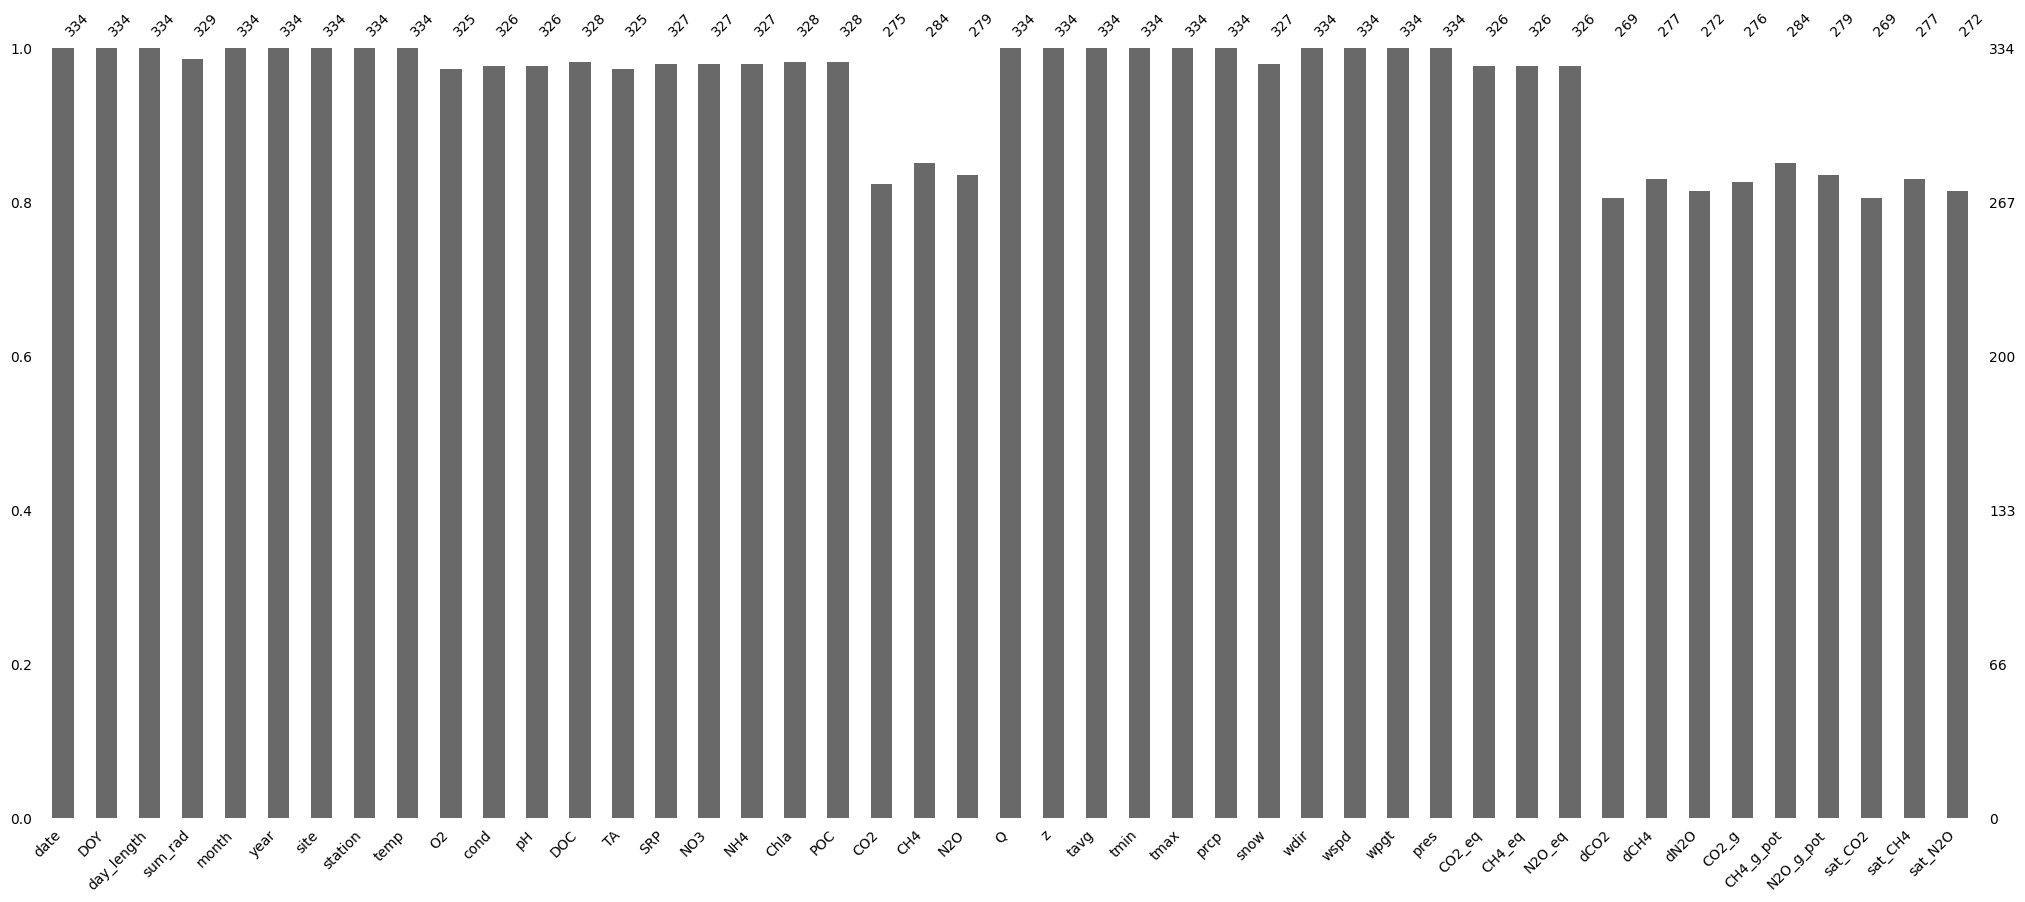

In [ ]:
missingno.bar(df1, fontsize = 10)
plt.show()

In [ ]:
df2 = df1.dropna(subset=['CO2', 'CH4', 'N2O'])
df2.shape

(273, 45)

In [ ]:
df2.describe()

,DOY,day_length,sum_rad,month,year,temp,O2,cond,pH,DOC,...,N2O_eq,dCO2,dCH4,dN2O,CO2_g,CH4_g_pot,N2O_g_pot,sat_CO2,sat_CH4,sat_N2O
count,273.000000,273.000000,268.000000,273.000000,273.000000,273.000000,266.000000,266.000000,266.000000,267.000000,...,266.000000,266.000000,266.000000,266.000000,273.000000,273.000000,273.000000,266.000000,266.000000,266.000000
mean,173.879121,12.087912,7132.587425,6.413919,2021.875458,13.498645,11.552594,921.312030,8.457756,6.227865,...,0.014925,12.646096,0.098967,0.003850,0.014307,0.000456,0.002238,156.308026,3084.044227,126.629851
std,96.237089,3.086909,4778.774345,3.184422,1.371675,7.180886,2.022053,234.325697,0.484953,1.861882,...,0.003703,20.299538,0.117258,0.005583,0.009877,0.000522,0.000828,101.142348,3835.178999,38.307276
min,11.000000,7.000000,423.160000,1.000000,2020.000000,1.500000,5.110000,100.000000,6.840000,3.540000,...,0.009389,-17.582305,-0.010766,-0.012251,0.000002,-0.000033,0.000862,0.030175,-216.095378,43.154252
25%,98.000000,9.500000,2868.060000,4.000000,2021.000000,6.200000,9.925000,755.000000,8.084500,5.285000,...,0.011621,-4.372795,0.029634,0.000845,0.005311,0.000151,0.001644,72.943933,826.377368,105.307928
50%,180.000000,13.000000,6909.025000,6.000000,2022.000000,14.500000,11.880000,883.000000,8.412500,5.840000,...,0.013781,11.009149,0.068487,0.003450,0.014520,0.000321,0.002079,145.655846,2061.741518,123.643508
75%,247.000000,14.500000,10750.690000,9.000000,2023.000000,19.900000,12.747500,1070.500000,8.839000,6.770000,...,0.018403,25.874215,0.120273,0.006133,0.021172,0.000554,0.002722,218.598271,3866.721646,142.588315
max,340.000000,16.500000,17414.730000,12.000000,2024.000000,26.970000,18.200000,1641.000000,10.400000,24.100000,...,0.022691,96.074123,0.842670,0.053485,0.054945,0.003801,0.007954,599.938099,25337.204290,520.857723


# Standortspezifische Verteilung Treibhausgase

<Figure size 1000x500 with 0 Axes>

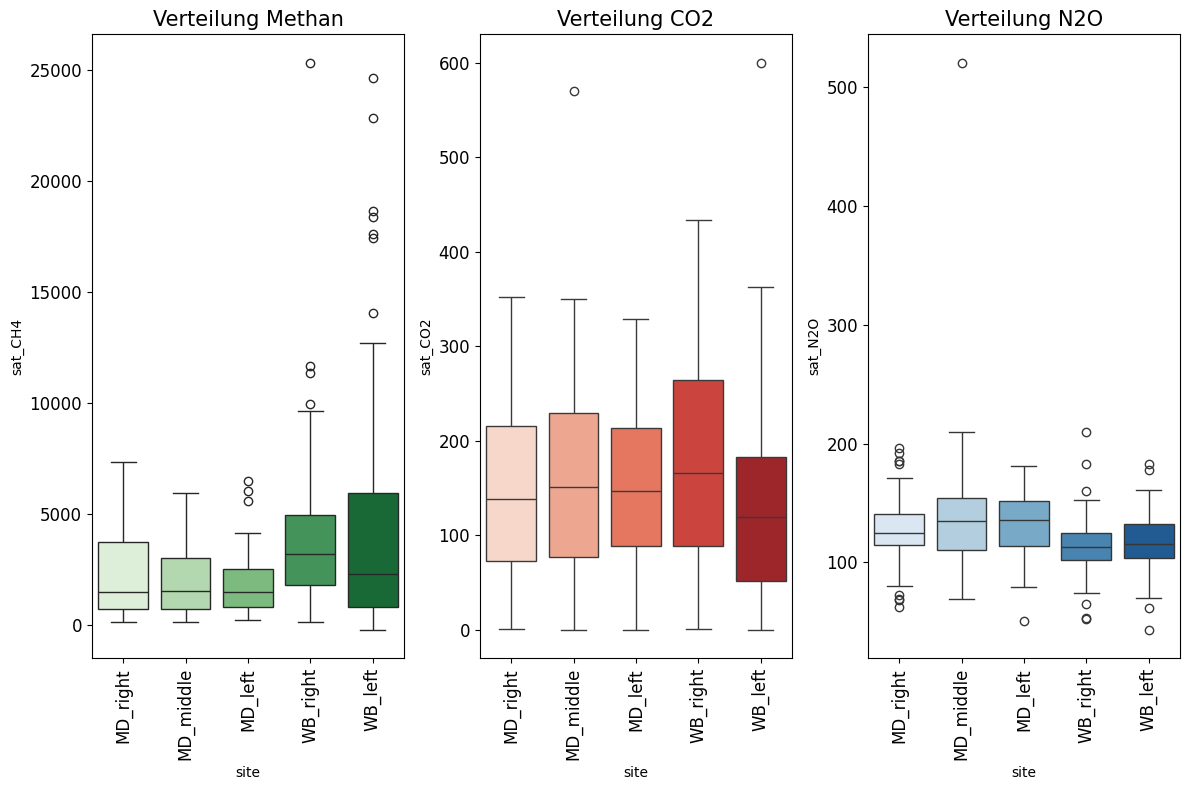

In [ ]:
plt.figure(figsize=(10,5))
plt.figure(figsize=(12,8))
plt.subplot(1,3,1)
plt.title('Verteilung Methan', fontsize = 15)
sns.boxplot(data=df2, x='site', y='sat_CH4', hue='site', palette=("Greens"))
plt.xticks(fontsize=12, rotation = 90)
plt.yticks(fontsize=12)
plt.subplot(1,3,2)
plt.title('Verteilung CO2', fontsize = 15)
sns.boxplot(data=df2, x='site', y='sat_CO2', hue='site', palette=("Reds"))
plt.xticks(fontsize=12, rotation = 90)
plt.yticks(fontsize=12)
plt.subplot(1,3,3)
plt.title('Verteilung N2O', fontsize = 15)
sns.boxplot(data=df2, x='site', y='sat_N2O', hue='site', palette=("Blues"))
plt.xticks(fontsize=12, rotation = 90)
plt.yticks(fontsize=12)
plt.tight_layout()

In [ ]:
df2_2 = df2.copy()

# Zeitreihen

In [ ]:
df2['date'] = pd.to_datetime(df2['date'], format="%d.%m.%Y",errors='coerce')
#df2['date'] = df2['date'].dt.strftime("%d.%m.%Y")
df2.set_index('date', inplace=True)

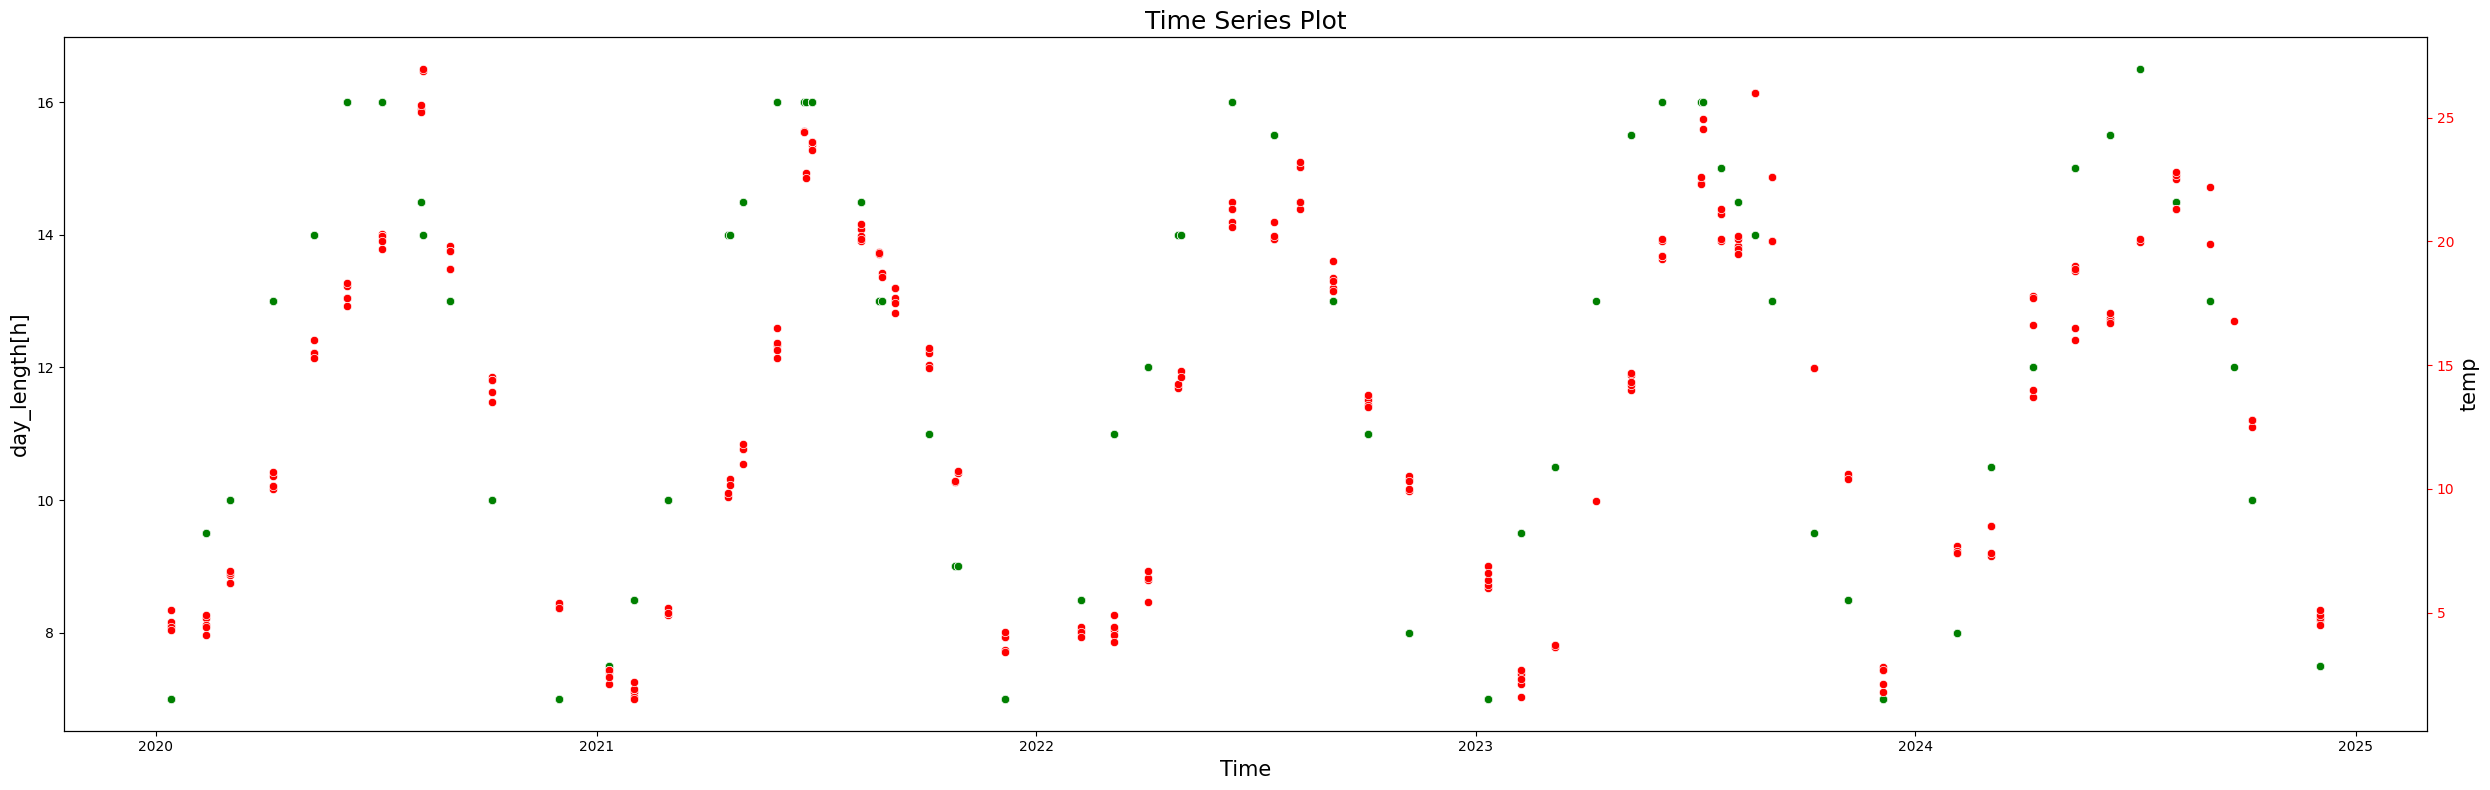

In [ ]:
plt.figure(figsize=(25,8))
ax1 = plt.subplot()
ax2 = ax1.twinx()
sns.scatterplot(df2['day_length'], color='green', ax=ax1)
sns.scatterplot(df2['temp'], color='red', ax=ax2)

ax2.tick_params(axis='y', colors='red')

plt.title('Time Series Plot', fontsize=18)
ax1.set_xlabel('Time', fontsize=15)
ax1.set_ylabel('day_length[h]', fontsize=15)
ax2.set_ylabel('temp', fontsize=15)

plt.tight_layout()
#plt.show()

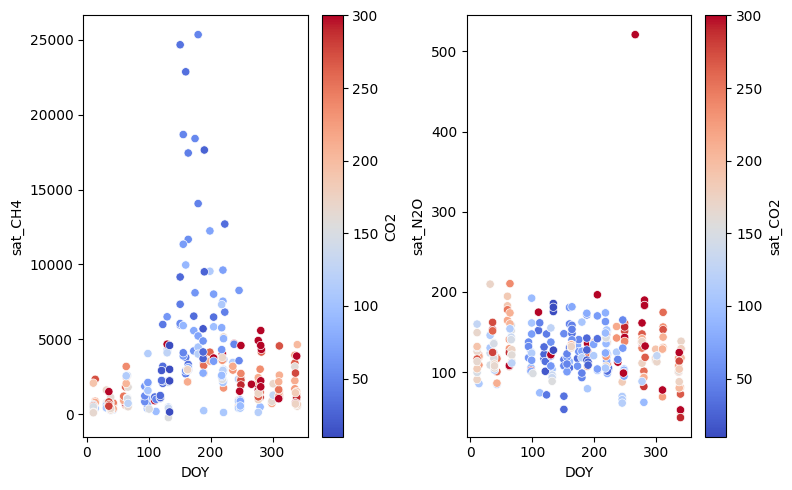

In [ ]:
norm = mcolors.Normalize(vmin=10, vmax=300)
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (8,5))
plt.subplot(1,2,1)
scatter = sns.scatterplot(x='DOY', y='sat_CH4', data=df2_2, hue = "sat_CO2", palette='coolwarm', hue_norm=norm, legend=False)
ax1.set_xlabel('DOY', fontsize=15)
#ax1.set_ylabel('CH4', fontsize=15)
#ax1.set_title("CH4 vs DOY",fontsize=12)
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=scatter.axes)
cbar.set_label("CO2")

plt.subplot(1,2,2)
scatter = sns.scatterplot(x='DOY', y='sat_N2O', data=df2_2, hue = "sat_CO2", palette='coolwarm', hue_norm=norm, legend = False)
ax2.set_xlabel('DOY', fontsize=15)
#ax2.set_ylabel('N2O', fontsize=15)
#ax2.set_title("N2O vs DOY",fontsize=12)

sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=scatter.axes)
cbar.set_label("sat_CO2")

plt.tight_layout()

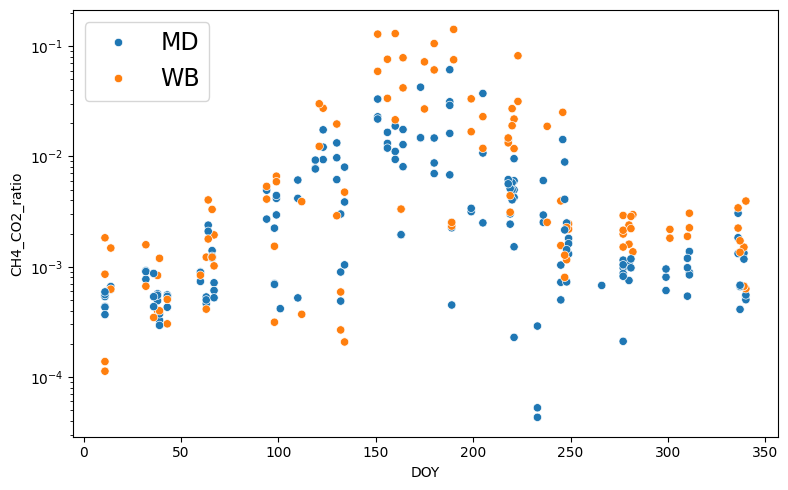

In [ ]:
from scipy.spatial import ConvexHull

df2_2['CH4_CO2_ratio'] = df2_2['CH4'] / df2_2['CO2']

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,5))
plt.subplot(1,1,1)
scatter = sns.scatterplot(x='DOY', y='CH4_CO2_ratio', hue='station', data=df2_2, legend=True)


ax1.set_xlabel('DOY', fontsize=17)
ax.set_yscale('log')
ax.legend(loc="upper left", fontsize=17)
plt.savefig(pfad_zur_csv+"saison_ratio_plot.jpg", format='jpg', dpi=100)
plt.tight_layout()

Bei der Berechnung der Sättigungswerte wird die Temperatur mit berücksichtigt (Bestandteil der Umrechnungsformel). Dabei zeigt sich, dass sowohl CO2 und CH4 trotzdem einen saisonalen Trend haben, während N2O nach der "Temperaturkorrektur" keinen Trend mehr zeigt.

**CH4 - hohe Werte im Sommer, CO2 hohe Werte im Winter**

## Beweis für Hypothese H2?

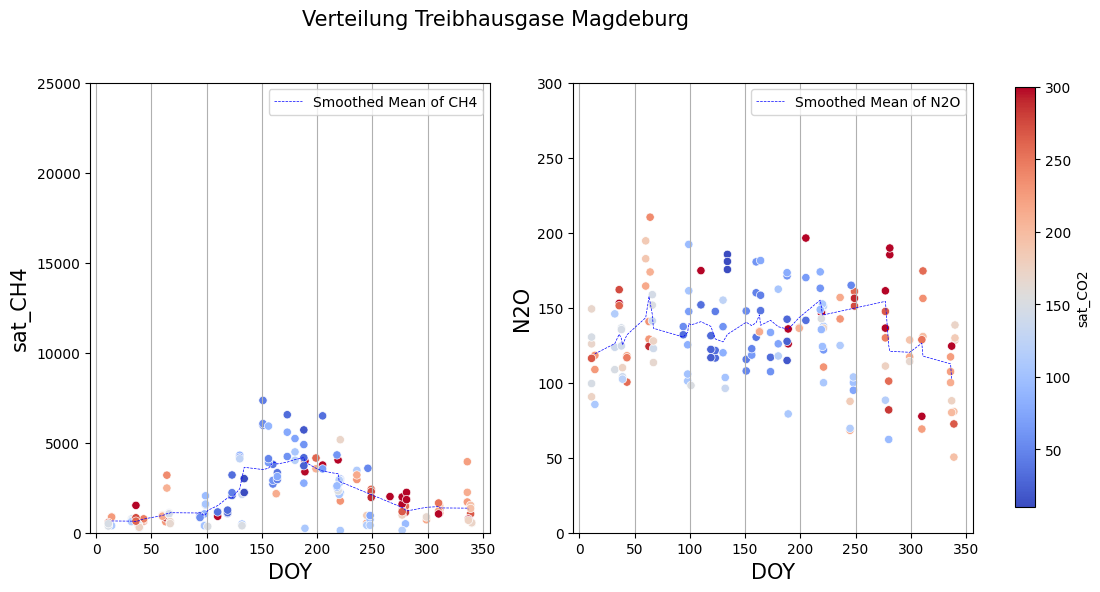

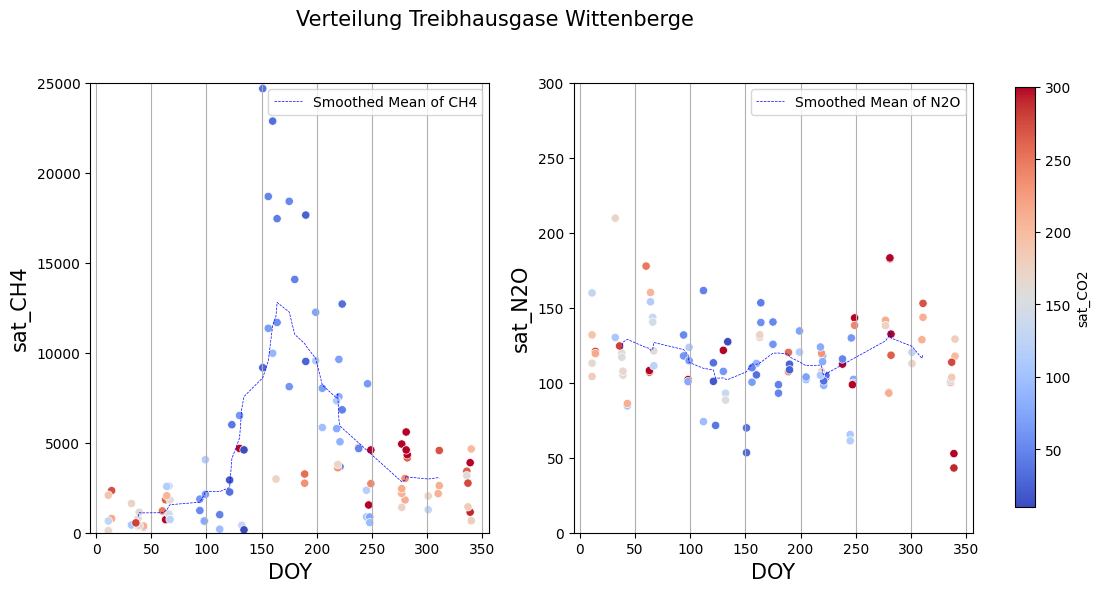

In [ ]:
df_MD=df2_2[df2_2['station'] == 'MD']
df_WB=df2_2[df2_2['station'] == 'WB']

df_MD_sorted = df_MD.sort_values('DOY')  # Nach DOY sortieren
df_MD_sorted['sat_N2O_smooth'] = df_MD_sorted['sat_N2O'].rolling(window=11, center=True).mean()

df_WB_sorted = df_WB.sort_values('DOY')  # Nach DOY sortieren
df_WB_sorted['sat_N2O_smooth'] = df_WB_sorted['sat_N2O'].rolling(window=17, center=True).mean()

df_MD_sorted['sat_CH4_smooth'] = df_MD_sorted['sat_CH4'].rolling(window=17, center=True).mean()
df_WB_sorted['sat_CH4_smooth'] = df_WB_sorted['sat_CH4'].rolling(window=17, center=True).mean()
df_MD_sorted = df_MD_sorted.dropna()
df_WB_sorted = df_WB_sorted.dropna()


norm = mcolors.Normalize(vmin=10, vmax=300)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))
fig.suptitle('Verteilung Treibhausgase Magdeburg', fontsize=15)
# Gleitende Durchschnittslinie für CH4 hinzufügen
sns.lineplot(x='DOY', y='sat_CH4_smooth', data=df_MD_sorted, ax=ax1, color='blue', ci=None, label='Smoothed Mean of CH4', linewidth=0.5, ls="--")
# Erster Scatterplot für CH4
scatter1 = sns.scatterplot(x='DOY', y='sat_CH4', data=df_MD, hue="sat_CO2", palette='coolwarm', hue_norm=norm, legend=False, ax=ax1)
ax1.set_xlabel('DOY', fontsize=15)
ax1.set_ylabel('sat_CH4', fontsize=15)
ax1.grid(True, axis='x')
ax1.set_ylim(0, 25000)


# Zweiter Scatterplot für N2O
scatter2 = sns.scatterplot(x='DOY', y='sat_N2O', data=df_MD, hue="sat_CO2", palette='coolwarm', hue_norm=norm, legend=False, ax=ax2)
ax2.set_xlabel('DOY', fontsize=15)
ax2.set_ylabel('N2O', fontsize=15)
ax2.grid(True, axis='x')
ax2.set_ylim(0, 300)

# Gleitende Durchschnittslinie für N2O hinzufügen
sns.lineplot(x='DOY', y='sat_N2O_smooth', data=df_MD_sorted, ax=ax2, color='blue', ci=None, label='Smoothed Mean of N2O', linewidth=0.5, ls="--")

# Gemeinsame Colorbar für beide Scatterplots
cbar_ax = fig.add_axes([1.02, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
cbar.set_label("sat_CO2")

plt.tight_layout(rect=[0, 0, 1, 0.95])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))
fig.suptitle('Verteilung Treibhausgase Wittenberge', fontsize=15)
# Gleitende Durchschnittslinie für CH4 hinzufügen
sns.lineplot(x='DOY', y='sat_CH4_smooth', data=df_WB_sorted, ax=ax1, color='blue', ci=None, label='Smoothed Mean of CH4', linewidth=0.5, ls="--")
# Erster Scatterplot für CH4
scatter1 = sns.scatterplot(x='DOY', y='sat_CH4', data=df_WB, hue="sat_CO2", palette='coolwarm', hue_norm=norm, legend=False, ax=ax1)
ax1.set_xlabel('DOY', fontsize=15)
ax1.set_ylabel('sat_CH4', fontsize=15)
ax1.grid(True, axis='x')
ax1.set_ylim(0, 25000)

# Gleitende Durchschnittslinie für N2O hinzufügen
sns.lineplot(x='DOY', y='sat_N2O_smooth', data=df_WB_sorted, ax=ax2, color='blue', ci = None, label='Smoothed Mean of N2O', linewidth=0.5, ls="--")
# Zweiter Scatterplot für N2O
scatter2 = sns.scatterplot(x='DOY', y='sat_N2O', data=df_WB, hue="sat_CO2", palette='coolwarm', hue_norm=norm, legend=False, ax=ax2)
ax2.set_xlabel('DOY', fontsize=15)
ax2.set_ylabel('sat_N2O', fontsize=15)
ax2.grid(True, axis='x')
ax2.set_ylim(0, 300)

# Gemeinsame Colorbar für beide Scatterplots
cbar_ax = fig.add_axes([1.02, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
cbar.set_label("sat_CO2")

plt.tight_layout(rect=[0, 0, 1, 0.95])

## Beweis für Hypothese 2 - standortspezifisch

# Korrelation der Variablen untereinander

In [ ]:
# noch mehr Spalten rausschmeißen --> meteorologische Werte
#df3_1 = df2_2.drop(['DOY','month','site','TA','prcp', 'snow', 'wdir', 'wspd', 'wpgt','pres', 'tavg','tmin','tmax','dCH4','dCO2','dN2O','CO2_eq','N2O_eq','CH4_eq','CO2_g','CH4_g_pot','N2O_g_pot'], axis=1)
# wir lassen alles drin für die Korrelationsanalyse
df3_1 = df1.drop(['DOY','month','site','TA','prcp', 'snow', 'wdir', 'wspd', 'wpgt','pres', 'tavg','tmin','tmax','dCH4','dCO2','dN2O','CO2_eq','N2O_eq','CH4_eq','CO2_g','CH4_g_pot','N2O_g_pot'], axis=1)
#df3_1 = pd.get_dummies(df3_1, columns=['station'], drop_first=False)
df3 = df3_1.drop(['year', 'z'], axis=1)

In [ ]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        334 non-null    object 
 1   day_length  334 non-null    float64
 2   sum_rad     329 non-null    float64
 3   station     334 non-null    object 
 4   temp        334 non-null    float64
 5   O2          325 non-null    float64
 6   cond        326 non-null    float64
 7   pH          326 non-null    float64
 8   DOC         328 non-null    float64
 9   SRP         327 non-null    float64
 10  NO3         327 non-null    float64
 11  NH4         327 non-null    float64
 12  Chla        328 non-null    float64
 13  POC         328 non-null    float64
 14  CO2         275 non-null    float64
 15  CH4         284 non-null    float64
 16  N2O         279 non-null    float64
 17  Q           334 non-null    int64  
 18  sat_CO2     269 non-null    float64
 19  sat_CH4     277 non-null    f

<Figure size 2500x2500 with 0 Axes>

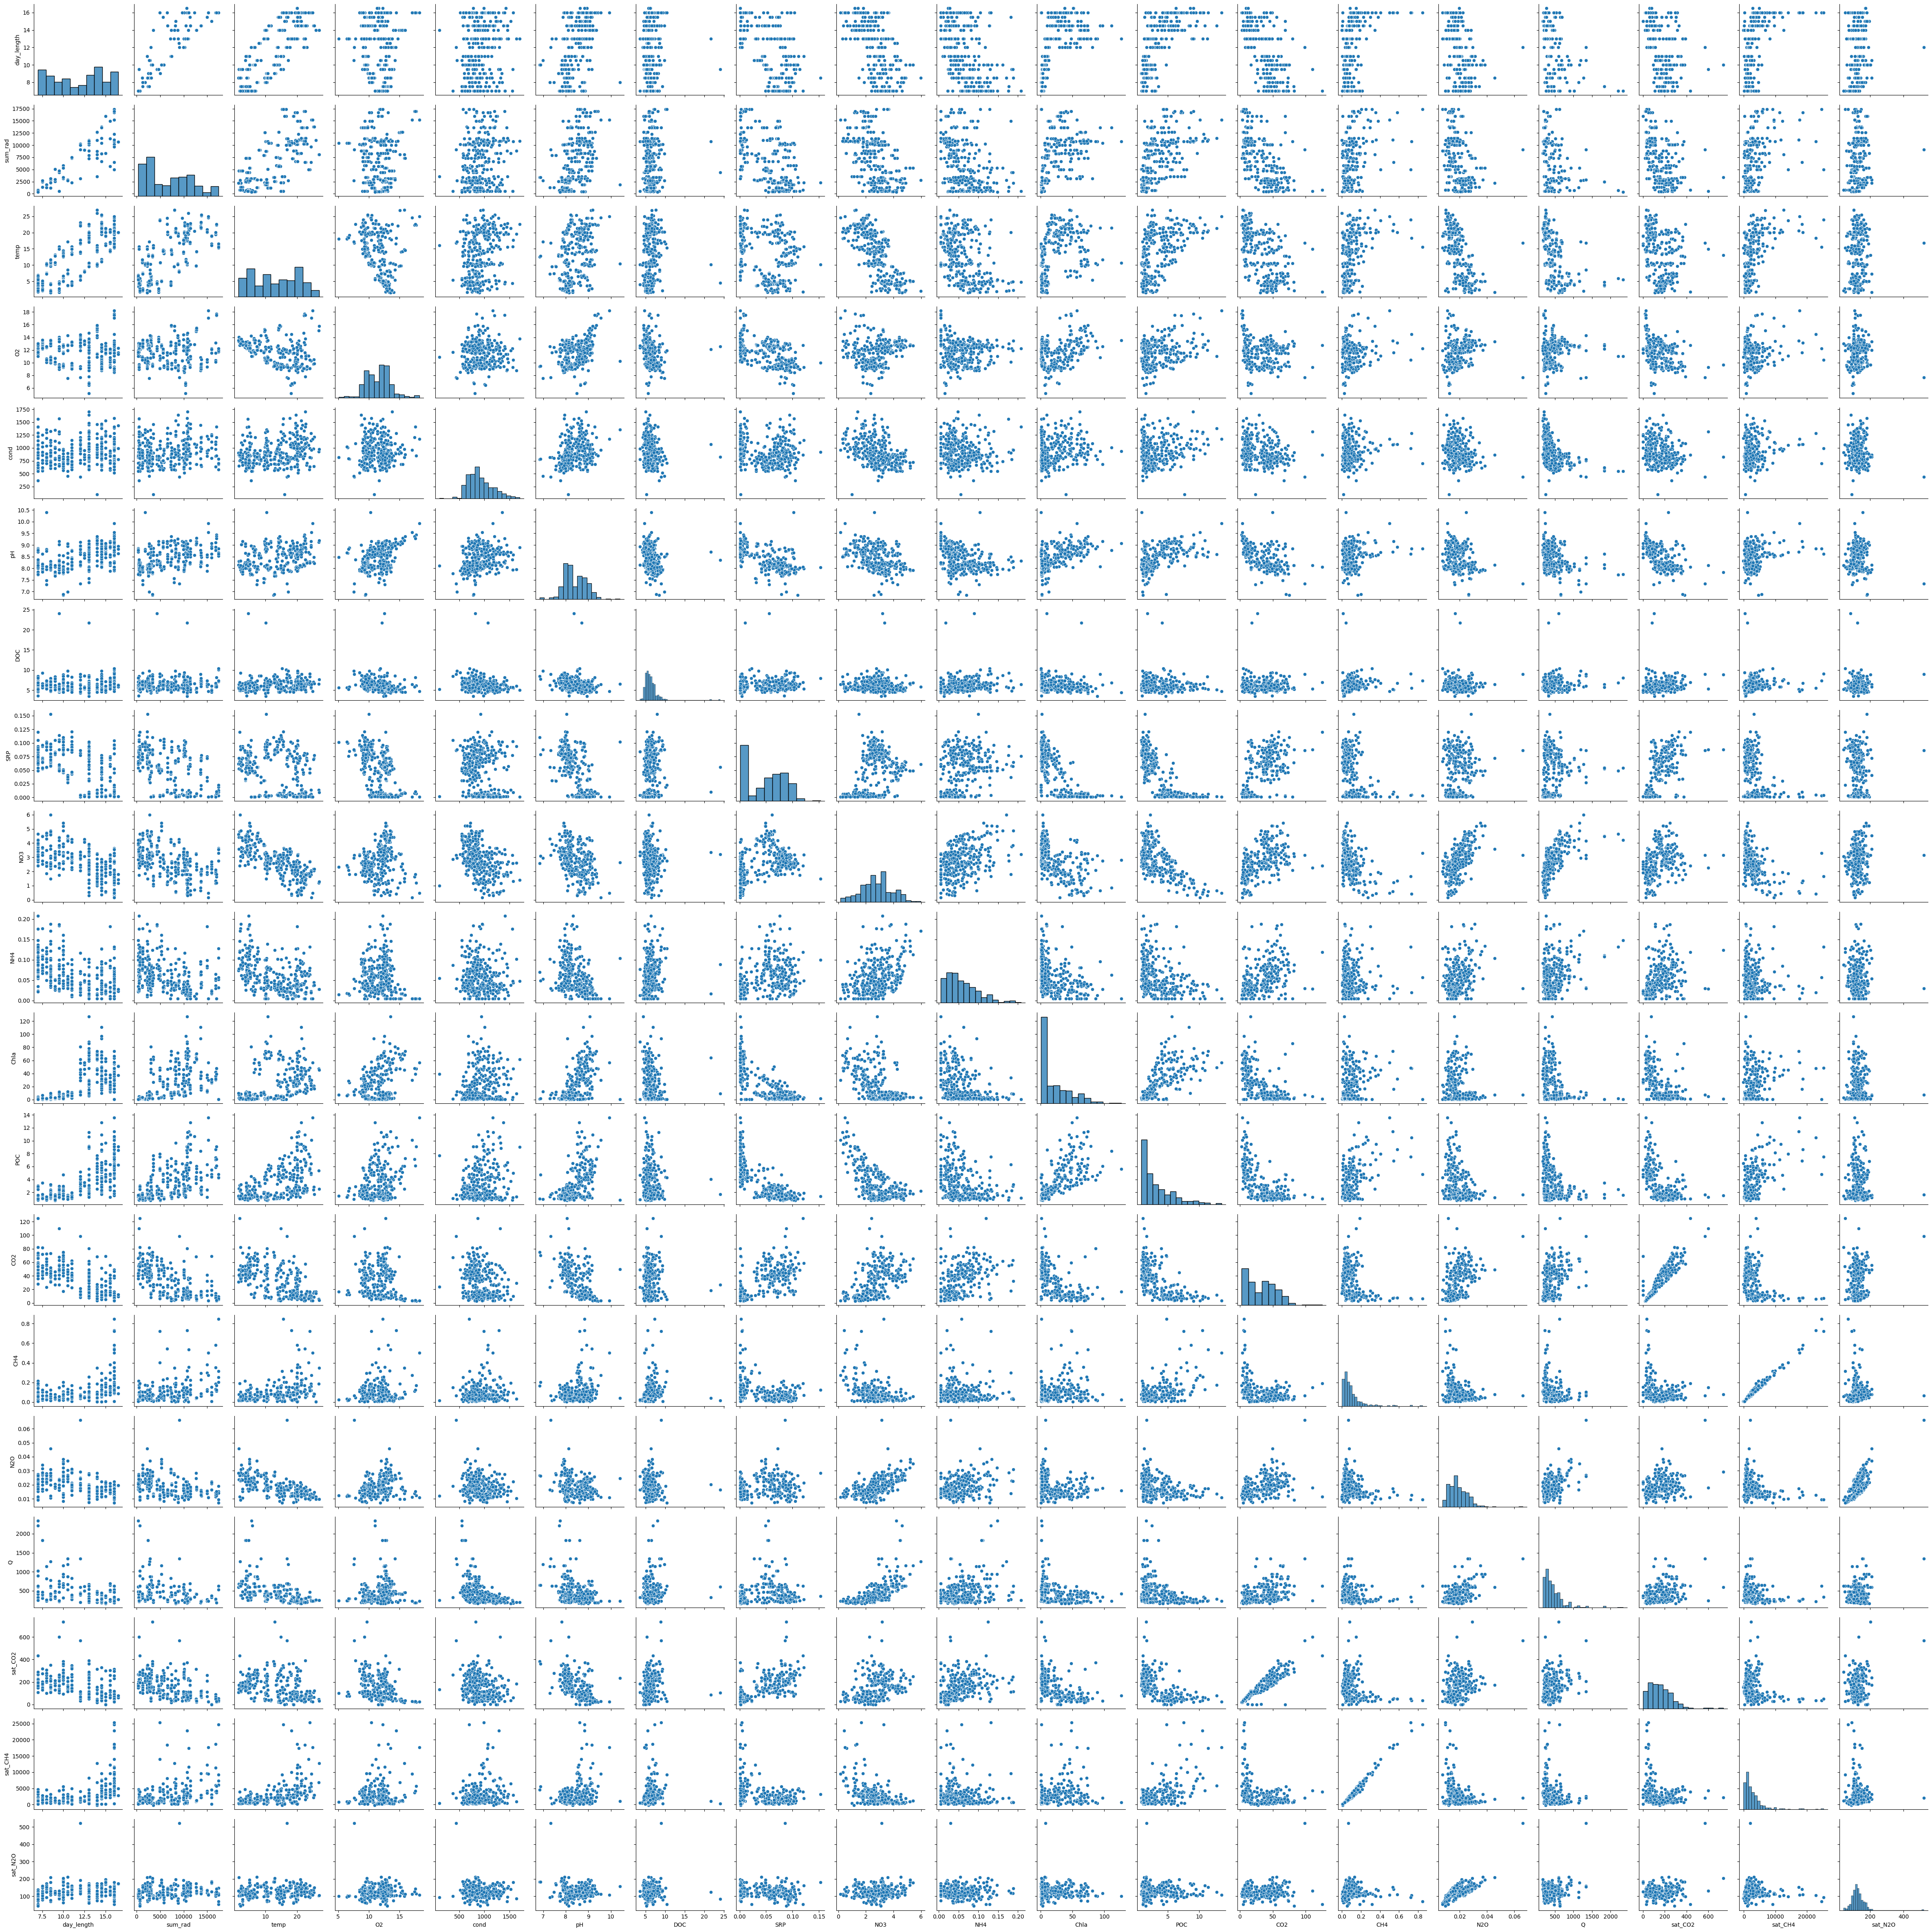

In [ ]:
plt.figure(figsize=(25,25))
sns.pairplot(df3)
plt.tight_layout()
plt.savefig(pfad_zur_csv+"pairplot.jpg", format='jpg', dpi=100)

**Was ist da in der Spalte Sauerstoff????**

**Ich bereinige das mal...**

In [ ]:
# Grenzwert definieren
threshold = 100

# Mittelwert der Spalte berechnen (nur Werte unterhalb des Grenzwerts berücksichtigen)
mean_value = df3[df3['O2'] <= threshold]['O2'].mean()

# Werte ersetzen, die größer als threshold sind
df3.loc[df3['O2'] > threshold, 'O2'] = mean_value

<Figure size 2500x2500 with 0 Axes>

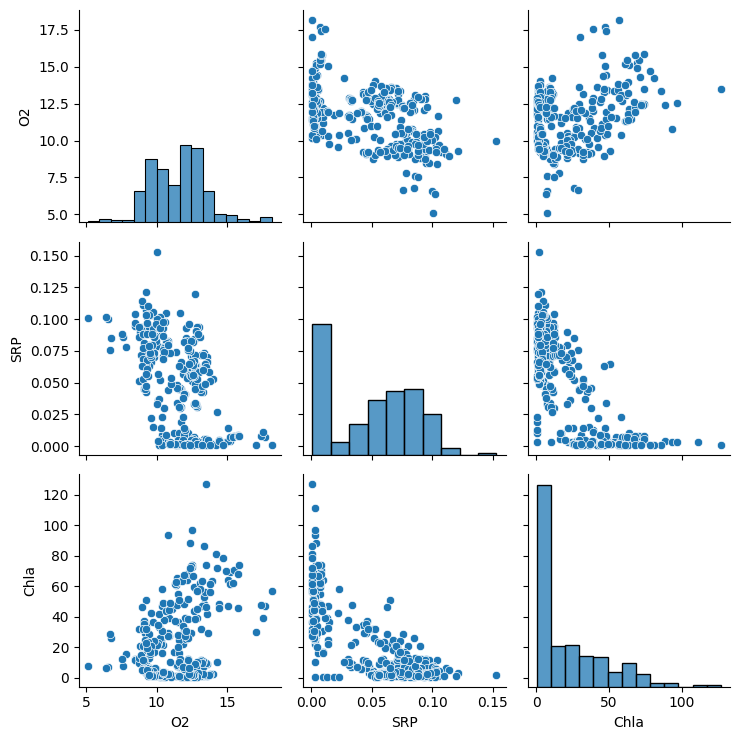

In [ ]:
selected_columns = ['O2', 'SRP', 'Chla']
plt.figure(figsize=(25,25))
sns.pairplot(df3[selected_columns])
plt.tight_layout()

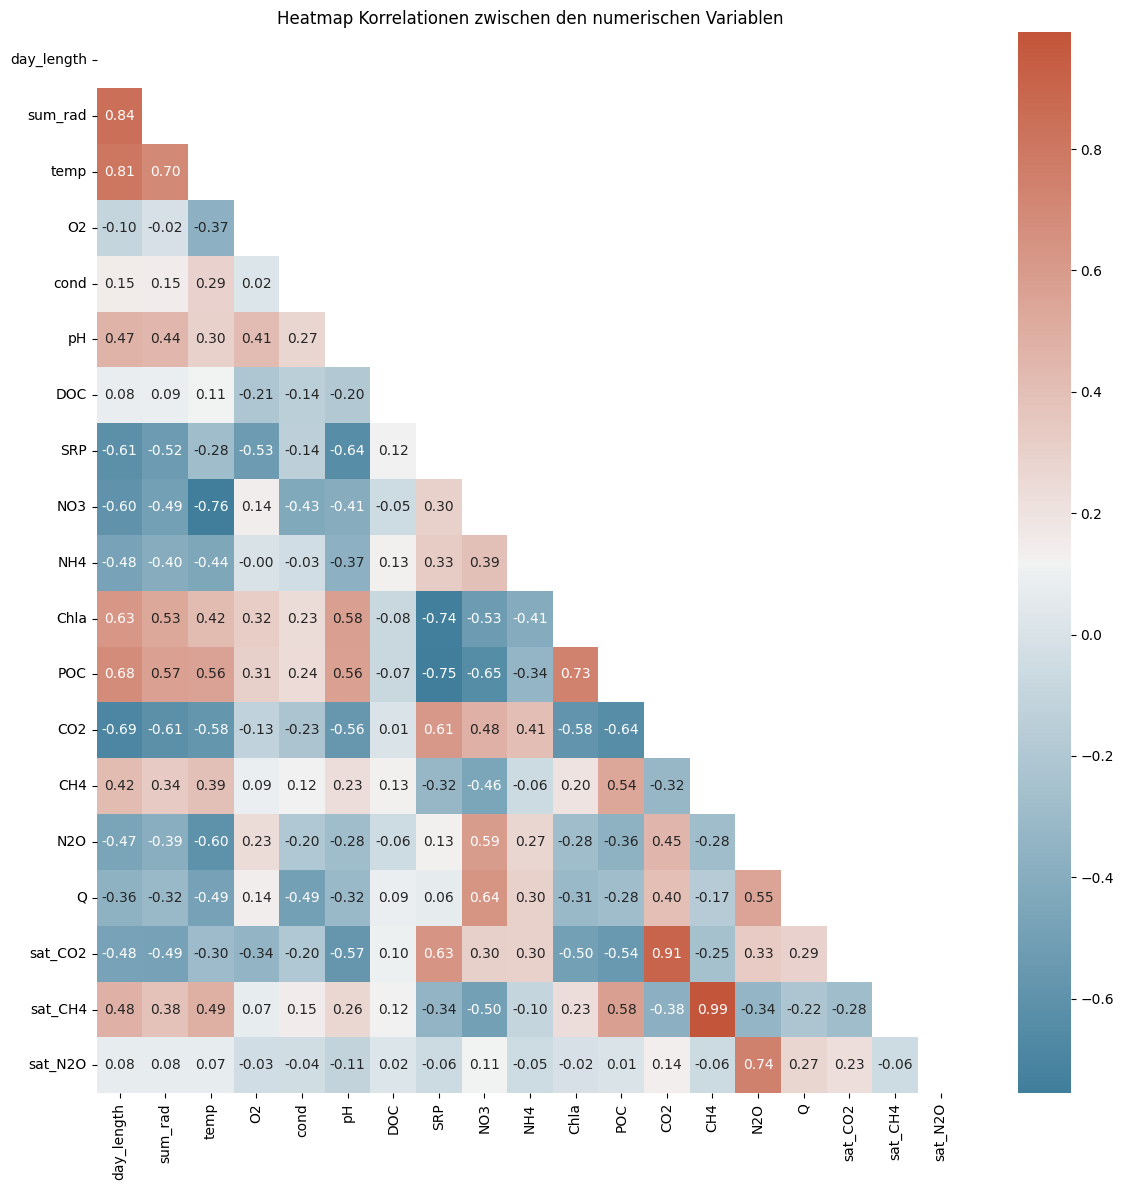

In [ ]:
df3['date'] = pd.to_datetime(df3['date'], format="%d.%m.%Y",errors='coerce')
corr=df3.select_dtypes(include=['float', 'int', 'bool']).corr()
fig_dims = (12, 12)
fig, ax = plt.subplots(figsize=fig_dims)
# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)
# Select only numeric columns for correlation calculation
sns.heatmap(corr,annot=True,mask=mask,ax=ax,cmap=cmap,fmt=".2f")
plt.title("Heatmap Korrelationen zwischen den numerischen Variablen",fontsize=12)
plt.savefig(pfad_zur_csv+"corr_matrix_all.png", dpi=300, bbox_inches="tight")
plt.tight_layout()

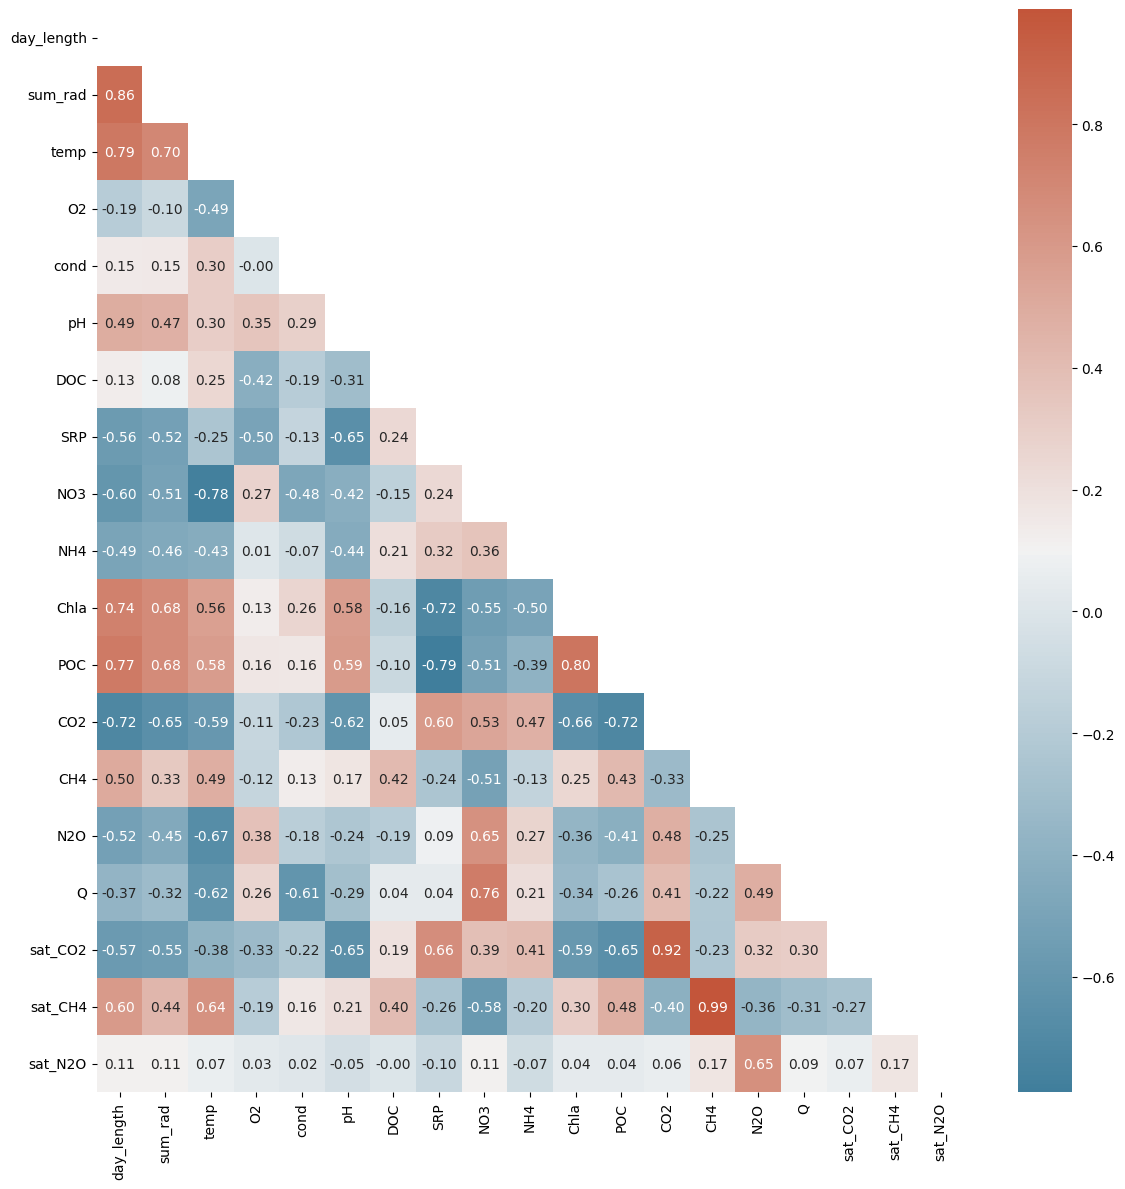

In [ ]:
df3['date'] = pd.to_datetime(df3['date'], format="%d.%m.%Y",errors='coerce')
corr=df3.select_dtypes(include=['float', 'int', 'bool']).corr(method='spearman')
fig_dims = (12, 12)
fig, ax = plt.subplots(figsize=fig_dims)
# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)
# Select only numeric columns for correlation calculation
sns.heatmap(corr,annot=True,mask=mask,ax=ax,cmap=cmap,fmt=".2f")
#plt.title("Heatmap Korrelationen zwischen den numerischen Variablen - Methode Spearman",fontsize=12)
plt.savefig(pfad_zur_csv+"corr_matrix_all.png", dpi=300, bbox_inches="tight")
plt.tight_layout()

# Heatmap standortspezifisch, saisonal!

Idee: Sommermonate day_length[h] > 12

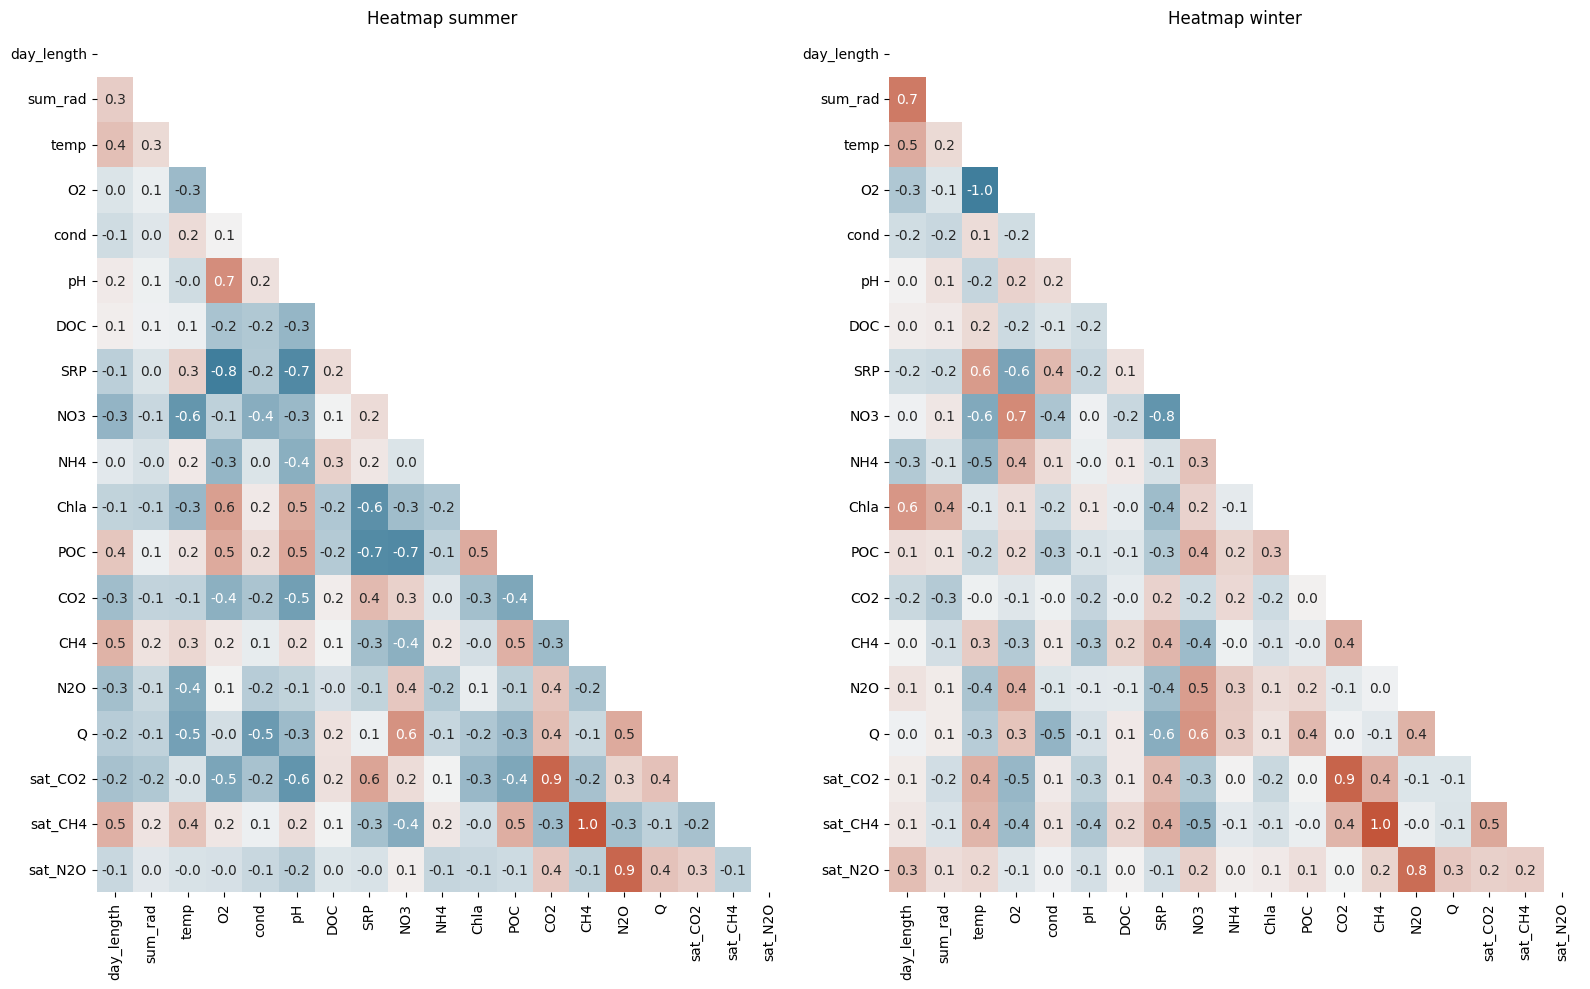

In [ ]:
df_summer=df3[df3['day_length'] > 11.5]
df_winter=df3[df3['day_length'] < 12]
corr_summer=df_summer.select_dtypes(include=['float', 'int', 'bool']).corr()
corr_winter=df_winter.select_dtypes(include=['float', 'int', 'bool']).corr()

fig1,(ax1,ax2) = plt.subplots(1,2,figsize=(16,10))
# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr_summer, dtype=bool))
# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)
# Select only numeric columns for correlation calculation
sns.heatmap(corr_summer,annot=True,mask=mask,ax=ax1,cmap=cmap,fmt=".1f",cbar=False)
ax1.set_title("Heatmap summer",fontsize=12)

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr_winter, dtype=bool))
# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)
# Select only numeric columns for correlation calculation
sns.heatmap(corr_winter,annot=True,mask=mask,ax=ax2,cmap=cmap,fmt=".1f",cbar=False)
ax2.set_title("Heatmap winter",fontsize=12)

plt.tight_layout()

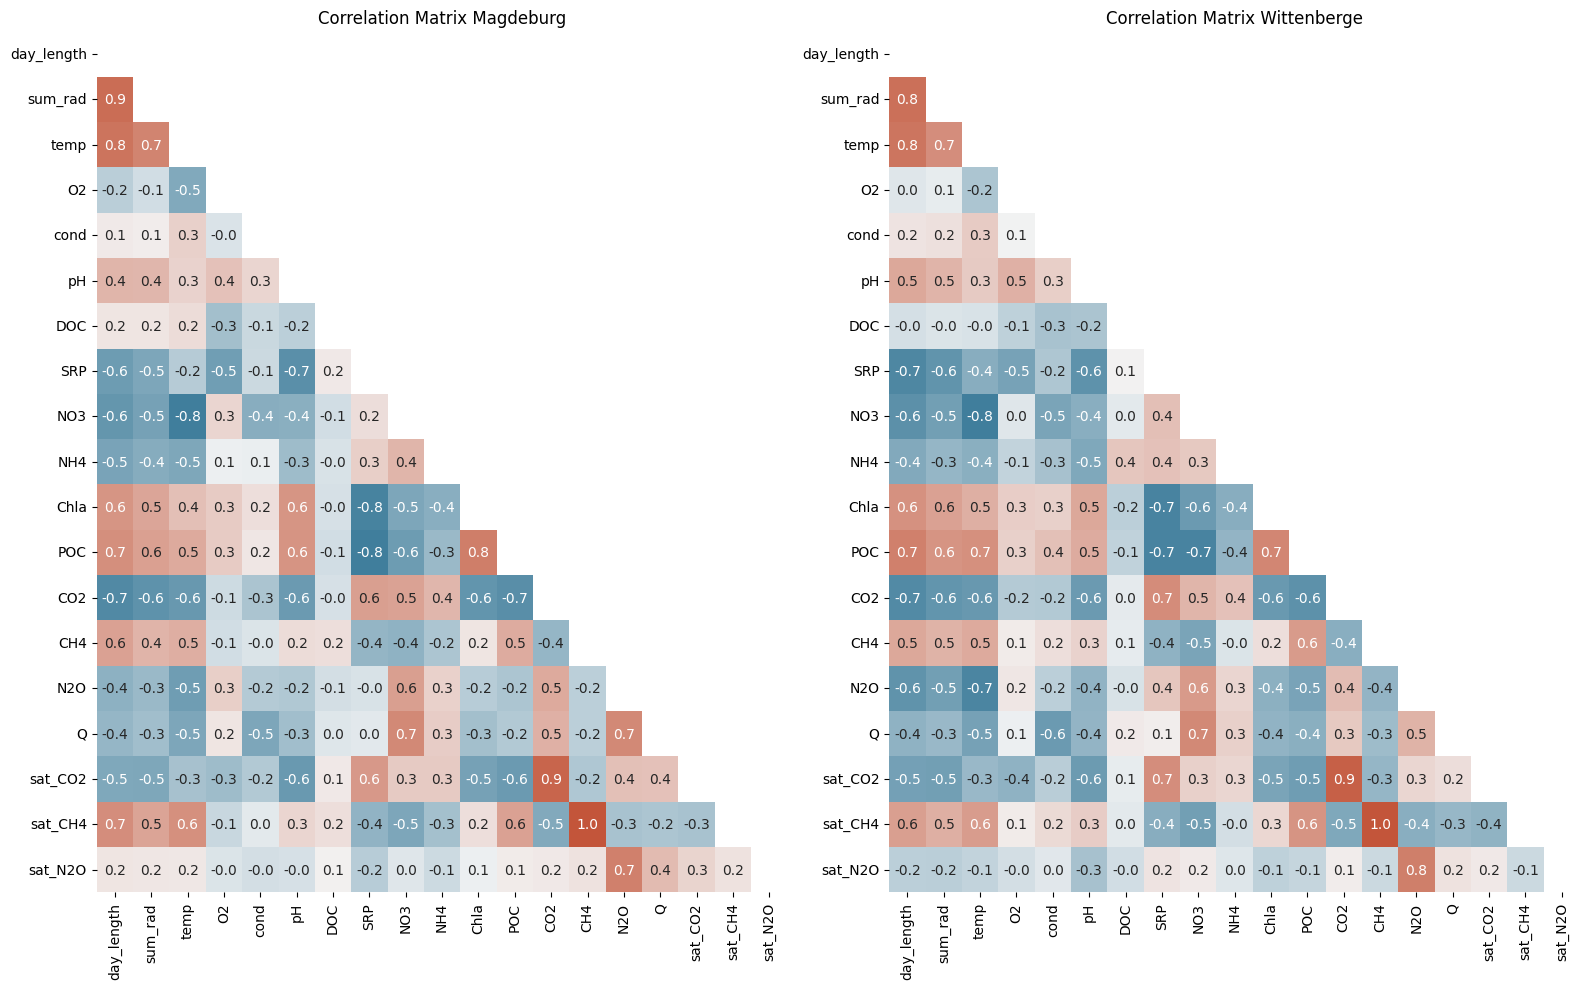

In [ ]:
df3 = pd.get_dummies(df3, columns=['station'], drop_first=False)
df_MD=df3[df3['station_MD'] == 1]
df_WB=df3[df3['station_WB'] == 1]
corr_MD=df_MD.select_dtypes(include=['float', 'int']).corr()
corr_WB=df_WB.select_dtypes(include=['float', 'int']).corr()

fig1,(ax1,ax2) = plt.subplots(1,2,figsize=(16,10))
# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr_MD, dtype=bool))
# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)
# Select only numeric columns for correlation calculation
sns.heatmap(corr_MD,annot=True,mask=mask,ax=ax1,cmap=cmap,fmt=".1f",cbar=False)
ax1.set_title("Correlation Matrix Magdeburg",fontsize=12)

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr_WB, dtype=bool))
# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)
# Select only numeric columns for correlation calculation
sns.heatmap(corr_WB,annot=True,mask=mask,ax=ax2,cmap=cmap,fmt=".1f",cbar=False)
ax2.set_title("Correlation Matrix Wittenberge",fontsize=12)

plt.savefig(pfad_zur_csv+"corr_matrix_WB_MD1.png", dpi=300, bbox_inches="tight")
plt.tight_layout()

In [ ]:
print(df3.columns)

Index(['date', 'day_length', 'sum_rad', 'temp', 'O2', 'cond', 'pH', 'DOC',
       'SRP', 'NO3', 'NH4', 'Chla', 'POC', 'CO2', 'CH4', 'N2O', 'Q', 'sat_CO2',
       'sat_CH4', 'sat_N2O', 'station_MD', 'station_WB'],
      dtype='object')


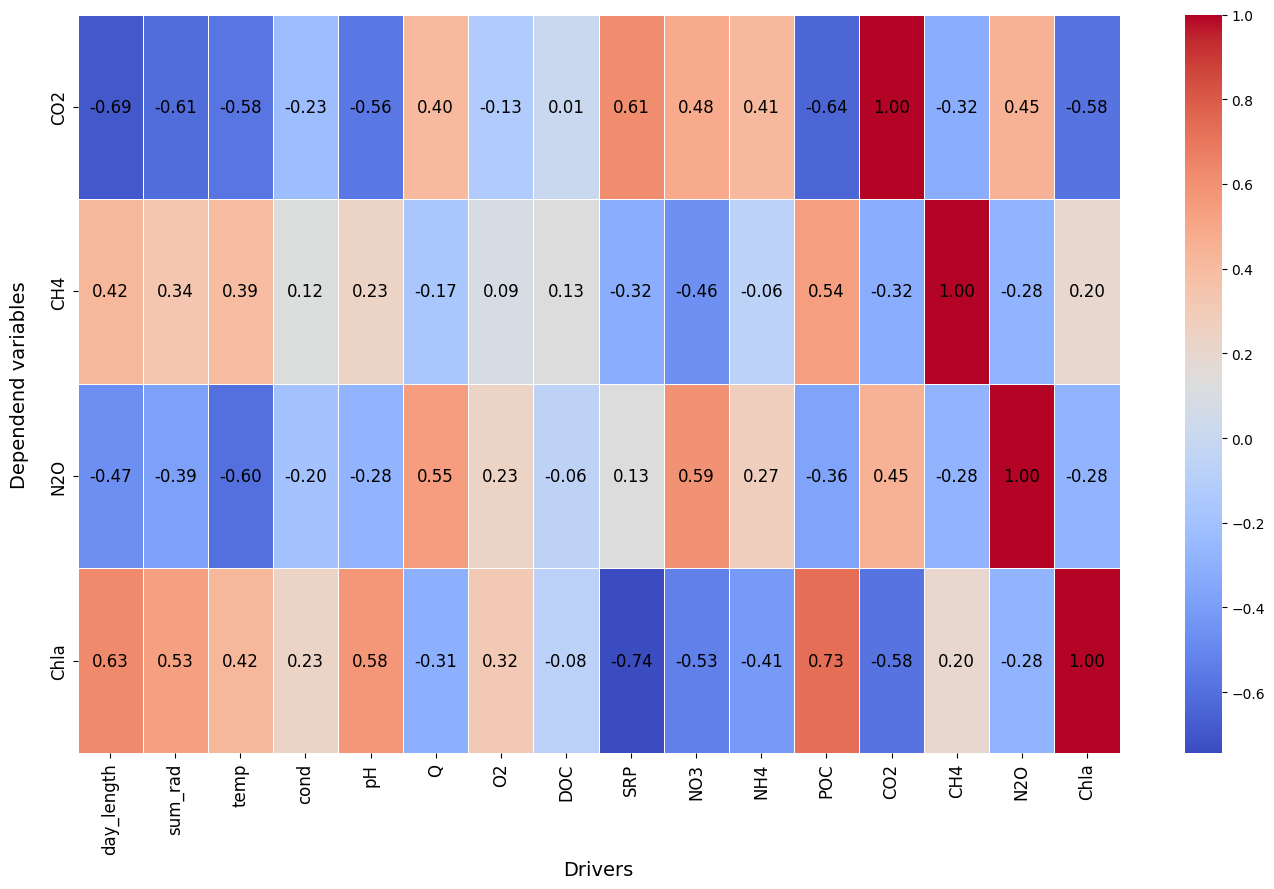

In [ ]:
# Gruppen definieren
affect_params = ['day_length', 'sum_rad', 'temp','cond', 'pH', 'Q', 'O2', 'DOC', 'SRP', 'NO3', 'NH4', 'POC','CO2', 'CH4', 'N2O', 'Chla']
gas_params = ['CO2', 'CH4', 'N2O', 'Chla']

# Extract sub-dataframes
df_abiotic = df3[affect_params]
df_biotic = df3[gas_params]

correlation_matrix = pd.DataFrame(
    [[df_abiotic[col_a].corr(df_biotic[col_b]) for col_a in affect_params] for col_b in gas_params],
    index=gas_params,
    columns=affect_params
)
# Compute correlation and p-value matrices
#correlation_matrix = pd.DataFrame(index=gas_params, columns=affect_params)
#p_value_matrix = pd.DataFrame(index=gas_params, columns=affect_params)


# Convert to float (optional, for better heatmap formatting)
#correlation_matrix = correlation_matrix.astype(float)
#p_value_matrix = p_value_matrix.astype(float)

# Plot the heatmap
plt.figure(figsize=(14, 9))
ax = sns.heatmap(correlation_matrix, annot=False, fmt="", cmap="coolwarm", linewidths=0.5)

# Manually add text with different font sizes
for i in range(correlation_matrix.shape[0]):
    for j in range(correlation_matrix.shape[1]):
        value = correlation_matrix.iloc[i, j]
        if not np.isnan(value):  # Ensure no NaN values
            text_size = 12 if abs(value) < 0.15 else 12  # Smaller font if correlation is below 0.15
            ax.text(j + 0.5, i + 0.5, f"{value:.2f}", ha='center', va='center', fontsize=text_size)
ax.tick_params(axis='both', labelsize=12)

#plt.title("Correlation Matrix: Target GHG concentrations", fontsize=14)
plt.xlabel("Drivers", fontsize=14)
plt.ylabel("Dependend variables", labelpad=15, fontsize=14)
plt.savefig(pfad_zur_csv+"small_corr_conc.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()


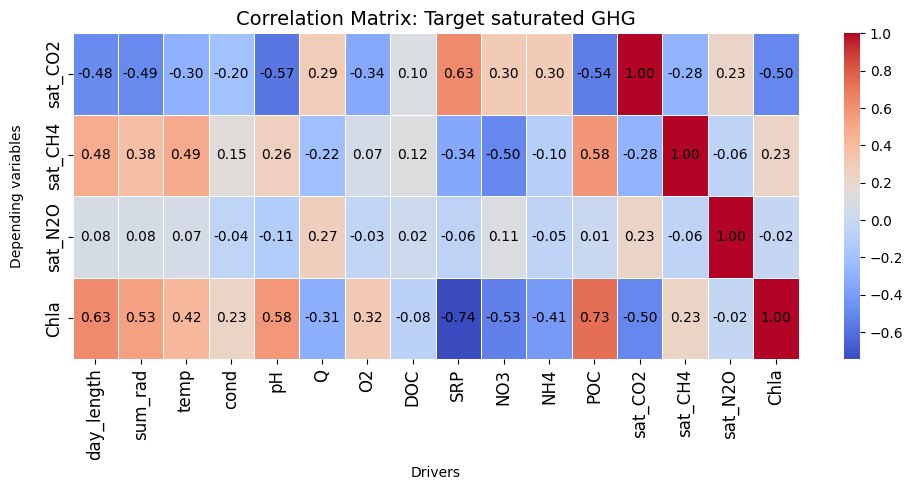

In [ ]:
# Gruppen definieren
affect_params = ['day_length', 'sum_rad', 'temp', 'cond', 'pH', 'Q', 'O2', 'DOC', 'SRP', 'NO3', 'NH4', 'POC', 'sat_CO2', 'sat_CH4', 'sat_N2O', 'Chla']
gas_params = ['sat_CO2', 'sat_CH4', 'sat_N2O', 'Chla']
# Extract sub-dataframes
df_abiotic = df3[affect_params]
df_biotic = df3[gas_params]

# Calculate correlations between the two groups
correlation_matrix = pd.DataFrame(
    [[df_abiotic[col_a].corr(df_biotic[col_b]) for col_a in affect_params] for col_b in gas_params],
    index=gas_params,
    columns=affect_params
)

# Plot the heatmap
plt.figure(figsize=(10, 5))
ax = sns.heatmap(correlation_matrix, annot=False, fmt="", cmap="coolwarm", linewidths=0.5)

# Manually add text with different font sizes
for i in range(correlation_matrix.shape[0]):
    for j in range(correlation_matrix.shape[1]):
        value = correlation_matrix.iloc[i, j]
        if not np.isnan(value):  # Ensure no NaN values
            text_size = 10 if abs(value) < 0.15 else 10  # Smaller font if correlation is below 0.15
            ax.text(j + 0.5, i + 0.5, f"{value:.2f}", ha='center', va='center', fontsize=text_size)
ax.tick_params(axis='both', labelsize=12)
plt.title("Correlation Matrix: Target saturated GHG", fontsize=14)
plt.xlabel("Drivers")
plt.ylabel("Depending variables", labelpad=15)
plt.savefig(pfad_zur_csv+"small_corr_sat.png", dpi=300, bbox_inches="tight")
plt.tight_layout()

plt.show()

In [ ]:
from scipy.stats import spearmanr
from scipy.stats import pearsonr

# Gruppen definieren
affect_params = ['day_length', 'sum_rad', 'temp', 'cond', 'pH', 'Q', 'O2', 'DOC', 'SRP', 'NO3', 'NH4', 'POC', 'station_MD', 'station_WB']
gas_params = ['sat_CO2', 'sat_CH4', 'sat_N2O', 'Chla']

# Spearman-Korrelation für jede Kombination berechnen
results = {}
for abiotic in affect_params:
    for biotic in gas_params:
        valid_data = df3[[abiotic, biotic]].dropna()
        #correlation, p_value = spearmanr(valid_data[abiotic], valid_data[biotic])
        correlation, p_value = pearsonr(valid_data[abiotic], valid_data[biotic])
        results[f"{abiotic} vs {biotic}"] = (correlation, p_value)

# Ergebnisse sortieren nach p-value (absteigend)
sorted_results = sorted(results.items(), key=lambda x: x[1][1], reverse=True)

# Sortierte Ergebnisse ausgeben
for pair, (corr, p) in sorted_results:
    print(f"{pair}: Pearson Correlation = {corr:.2f}, p-value = {p:.3f}")

POC vs sat_N2O: Pearson Correlation = 0.01, p-value = 0.889
station_MD vs sat_CO2: Pearson Correlation = 0.01, p-value = 0.844
station_WB vs sat_CO2: Pearson Correlation = -0.01, p-value = 0.844
DOC vs sat_N2O: Pearson Correlation = 0.02, p-value = 0.731
O2 vs sat_N2O: Pearson Correlation = -0.03, p-value = 0.586
cond vs sat_N2O: Pearson Correlation = -0.04, p-value = 0.460
NH4 vs sat_N2O: Pearson Correlation = -0.05, p-value = 0.384
SRP vs sat_N2O: Pearson Correlation = -0.06, p-value = 0.319
temp vs sat_N2O: Pearson Correlation = 0.07, p-value = 0.239
O2 vs sat_CH4: Pearson Correlation = 0.07, p-value = 0.223
day_length vs sat_N2O: Pearson Correlation = 0.08, p-value = 0.213
sum_rad vs sat_N2O: Pearson Correlation = 0.08, p-value = 0.206
DOC vs Chla: Pearson Correlation = -0.08, p-value = 0.170
NH4 vs sat_CH4: Pearson Correlation = -0.10, p-value = 0.105
DOC vs sat_CO2: Pearson Correlation = 0.10, p-value = 0.088
NO3 vs sat_N2O: Pearson Correlation = 0.11, p-value = 0.066
pH vs sat_N

# **Versuch --> Vorhersage der CH4 Konzentration mit Random Forest und Gradient Boosting**

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn import metrics
from sklearn.model_selection import GridSearchCV

In [ ]:
df4 = df3_1.dropna(subset=['sat_CO2', 'sat_CH4', 'sat_N2O'])
#df4 = pd.get_dummies(df4, columns=['station'], drop_first=False)
df4_train = df4.copy()
df4_train = df4.loc[df4['year'] != 2020]
df4_test = df4.loc[df4['year'] == 2020]
#df4_test.shape
df4.columns

Index(['date', 'day_length', 'sum_rad', 'year', 'station', 'temp', 'O2',
       'cond', 'pH', 'DOC', 'SRP', 'NO3', 'NH4', 'Chla', 'POC', 'CO2', 'CH4',
       'N2O', 'Q', 'z', 'sat_CO2', 'sat_CH4', 'sat_N2O'],
      dtype='object')

In [ ]:
df4_test.shape

(55, 23)

In [ ]:
df4_2 = df4_train.dropna()
x = df4_2.drop(columns=['year', 'sat_CO2', 'sat_CH4', 'sat_N2O', 'CO2', 'CH4', 'N2O','date', 'station'], axis=1)
y = df4_2['sat_CH4']

In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 210 entries, 65 to 333
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   day_length  210 non-null    float64
 1   sum_rad     210 non-null    float64
 2   temp        210 non-null    float64
 3   O2          210 non-null    float64
 4   cond        210 non-null    float64
 5   pH          210 non-null    float64
 6   DOC         210 non-null    float64
 7   SRP         210 non-null    float64
 8   NO3         210 non-null    float64
 9   NH4         210 non-null    float64
 10  Chla        210 non-null    float64
 11  POC         210 non-null    float64
 12  Q           210 non-null    int64  
 13  z           210 non-null    float64
dtypes: float64(13), int64(1)
memory usage: 24.6 KB


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Random Forest

In [ ]:
param_grid_rf= {
    'n_estimators': [100,200],
    'max_features': ['log2', None],
    'max_depth': [3,6,8],
    'max_leaf_nodes': [None,10,20],
}

In [ ]:
gridsearchRF=GridSearchCV(estimator=RandomForestRegressor(), param_grid=param_grid_rf, cv=5,scoring='r2')
gridsearchRF.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [3, 6, 8], 'max_features': ['log2', None],
                         'max_leaf_nodes': [None, 10, 20],
                         'n_estimators': [100, 200]},
             scoring='r2')

In [ ]:
gridsearchRF.best_params_

{'max_depth': 6,
 'max_features': 'log2',
 'max_leaf_nodes': None,
 'n_estimators': 100}

In [ ]:
# Modell fitten
rf=gridsearchRF.best_estimator_.fit(X_train,y_train)

In [ ]:
# Vorhersagen auf Testdaten
y_pred = rf.predict(X_test)

# Evaluierung der Modellgüte
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²-Score: {r2:.3f}")

MAE: 1099.98
MSE: 2502943.58
RMSE: 1582.07
R²-Score: 0.729


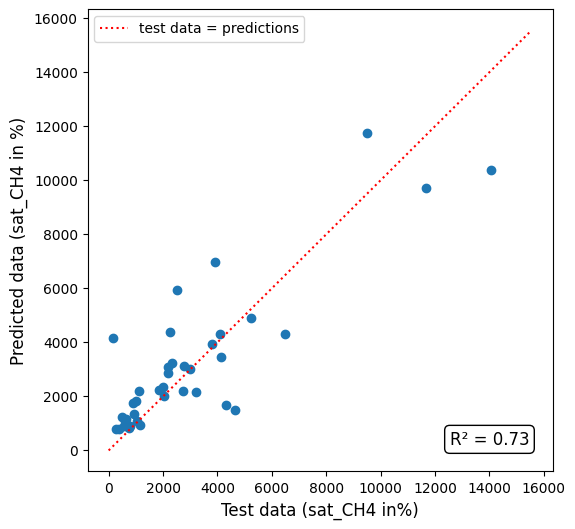

In [ ]:
def linear_function(x):
    return 1* x

x_range = np.linspace(0, 15550, 10)
y_function = linear_function(x_range)

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 6))  # Define 'ax' properly
ax.plot(x_range, y_function, label='test data = predictions', color='red', linestyle=":")
ax.scatter(y_test, y_pred)

# Titles and labels
#fig.suptitle('Comparison test data - predicted data (Random Forest)', fontsize=15)
ax.set_xlabel('Test data (sat_CH4 in%)', fontsize=12)
ax.set_ylabel('Predicted data (sat_CH4 in %)', fontsize=12)

# Add R² text in bottom right
ax.text(0.95, 0.05, f"R² = {r2:.2f}", transform=ax.transAxes,
        fontsize=12, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

ax.legend()
plt.savefig(pfad_zur_csv + "compare_rf.png", dpi=300, bbox_inches="tight")
plt.show()

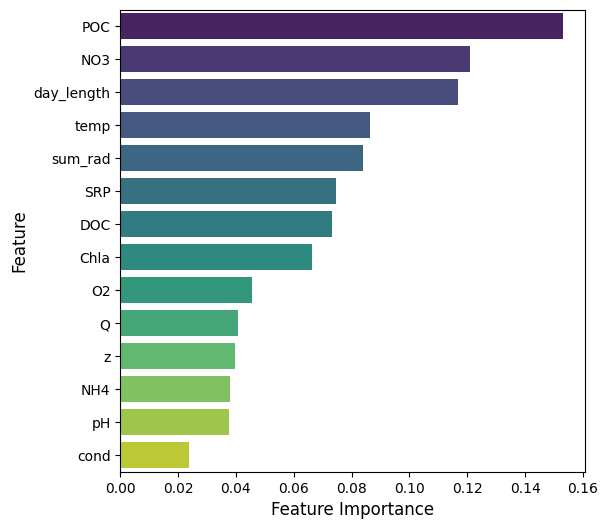

In [ ]:
# Feature Importance extrahieren
importances = rf.feature_importances_
feature_names = x.columns

# Sortierte Plot-Darstellung
sorted_indices = np.argsort(importances)[::-1]
plt.figure(figsize=(6, 6))
sns.barplot(x=importances[sorted_indices], y=[feature_names[i] for i in sorted_indices], palette="viridis")
plt.xlabel("Feature Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
#plt.title("Feature Importance Random Forest")
plt.savefig(pfad_zur_csv + "Feat_imp_rf.png", dpi=300, bbox_inches="tight")
plt.show()

## Gradient Boosting

In [ ]:
param_grid_gb = {
    'n_estimators': [50, 100,200,300],          # Anzahl der Bäume
    'learning_rate': [0.1, 0.2],             # Lernrate
    'max_depth': [3,6]                   # Maximale Tiefe der Bäume
}

In [ ]:
# GridSearchCV-Objekt erstellen
gridsearchGB = GridSearchCV(
    estimator=GradientBoostingRegressor(),
    param_grid=param_grid_gb,
    cv=5,                         # 5-fache Cross-Validation
    scoring='r2',                 # Bewertung basierend auf R²
    n_jobs=-1,                    # Parallelverarbeitung
    verbose=1                     # Fortschrittsanzeige
)

In [ ]:
# Grid Search auf den Trainingsdaten durchführen
gb = gridsearchGB.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


In [ ]:
# Beste Parameter und Modellgüte ausgeben
print("Beste Parameter:", gridsearchGB.best_params_)

Beste Parameter: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


In [ ]:
best_model_gb = gridsearchGB.best_estimator_
y_pred2_best = best_model_gb.predict(X_test)
r2_2_best=r2_score(y_pred2_best, y_test)
r2_2_best

0.9479459854144533

In [ ]:
mae = mean_absolute_error(y_test, y_pred2_best)
mae

332.9451644525753

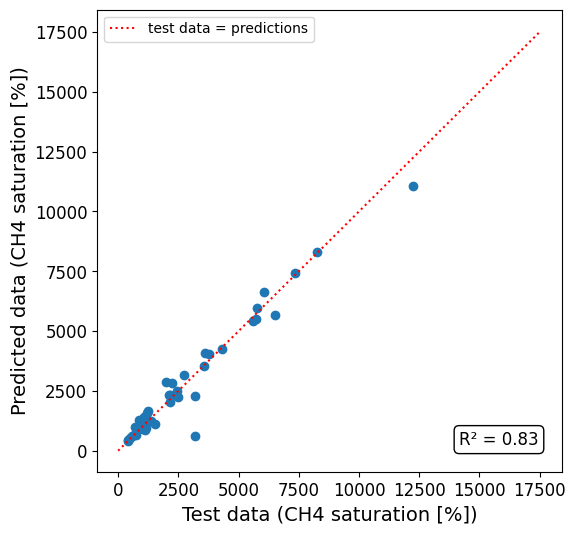

In [ ]:
def linear_function(x):
    return 1* x

x_range = np.linspace(0, 17550, 10)
y_function = linear_function(x_range)

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 6))  # Define 'ax' properly
ax.plot(x_range, y_function, label='test data = predictions', color='red', linestyle=":")
ax.scatter(y_test, y_pred2_best)

# Titles and labels
#fig.suptitle('Comparison test data - predicted data (Gradient Boosting)', fontsize=15)
ax.set_xlabel('Test data (CH4 saturation [%])', fontsize=14)
ax.set_ylabel('Predicted data (CH4 saturation [%])', fontsize=14)
ax.tick_params(axis='both', labelsize=12)
# Add R² text in bottom right
ax.text(0.95, 0.05, f"R² = 0.83", transform=ax.transAxes,
        fontsize=12, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

ax.legend()
plt.savefig(pfad_zur_csv + "compare_gb.png", dpi=300, bbox_inches="tight")
plt.show()

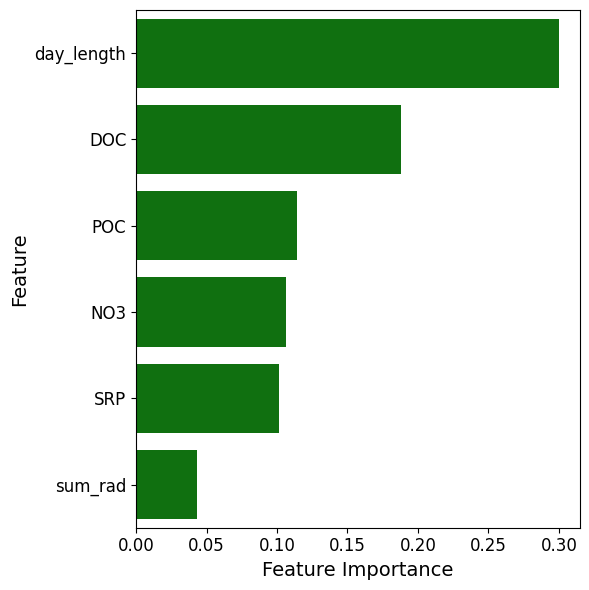

In [ ]:
# Feature Importance extrahieren
importances = best_model_gb.feature_importances_
feature_names = x.columns

# Sortierte Indizes und Auswahl der Top 6
sorted_indices = np.argsort(importances)[::-1][:6]
top_features = [feature_names[i] for i in sorted_indices]
top_importances = importances[sorted_indices]

# Plot
plt.figure(figsize=(6, 6))
sns.barplot(x=top_importances, y=top_features, color="green")  # Einfarbig (z. B. grau)
plt.xlabel("Feature Importance", fontsize=14)
plt.ylabel("Feature", fontsize=14)
plt.tick_params(axis='both', labelsize=12)
# plt.title("Top 6 Features - Gradient Boosting")
plt.tight_layout()
plt.savefig(pfad_zur_csv + "Feat_imp_gb_top6.png", dpi=300, bbox_inches="tight")
plt.show()

## Anwenden des Modells auf die Daten von 2020

In [ ]:
df4_3 = df4_test.dropna()
x = df4_3.drop(columns=['year','sat_CO2', 'sat_CH4', 'sat_N2O', 'CO2', 'CH4', 'N2O','date','station','z'], axis=1)
y = df4_3['sat_CH4']

In [ ]:
df4_3['date'] = pd.to_datetime(df4_3['date'], format="%d.%m.%Y",errors='coerce')

In [ ]:
df4_3['sat_CH4_pred_gb'] = best_model_gb.predict(x)
df4_3['sat_CH4_pred_rf'] = rf.predict(x)

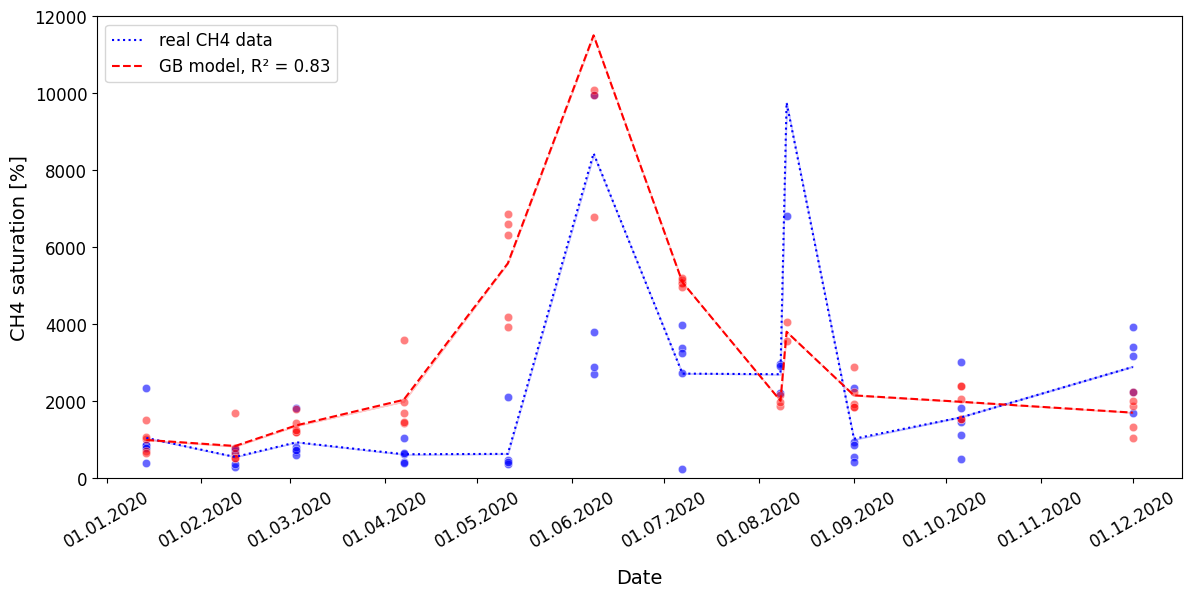

In [ ]:
# Plot erstellen
plt.figure(figsize=(14, 6))

# Tatsächliche Werte (blaue Linie)
sns.scatterplot(x=df4_3['date'], y=df4_3['sat_CH4'], color="blue", marker="o", alpha=0.6)
sns.lineplot(x=df4_3['date'], y=df4_3['sat_CH4'], label="real CH4 data", color="blue", ci=0.98, linestyle=":")

# Modellierte Werte (rote gestrichelte Linie)
sns.scatterplot(x=df4_3['date'], y=df4_3['sat_CH4_pred_gb'], color="red", marker="o", alpha=0.5)
sns.lineplot(x=df4_3['date'], y=df4_3['sat_CH4_pred_gb'], label="GB model, R² = 0.83", ci=0.98, color="red", linestyle="--")

# Modellierte Werte (rote gestrichelte Linie)
#sns.scatterplot(x=df4_3['date'], y=df4_3['sat_CH4_pred_rf'], color="green", marker="o", alpha=0.5)
#sns.lineplot(x=df4_3['date'], y=df4_3['sat_CH4_pred_rf'], label="RF model, R² = 0.75", ci=0.98, color="green", linestyle="-.")

# Achsenbeschriftung & Titel
# Gleichmäßige Zeitabstände auf der x-Achse
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))  # Jeden Monat anzeigen
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m.%Y"))  # Datum im Format Tag.Monat.Jahr
#ax.set_yscale('log')
ax.set_ylim(0, 12000)
plt.xlabel("Date", fontsize=14, labelpad=12)
plt.ylabel("CH4 saturation [%]",fontsize=14)
plt.tick_params(axis='both', labelsize=12)
#plt.title("Compared real and predicted data for year 2020 (test dataset)")
plt.legend(loc="upper left", fontsize=12)

# Zeitachse rotieren für bessere Lesbarkeit
plt.xticks(rotation=30)
plt.savefig(pfad_zur_csv+"compare_model_plot_2020_linscale.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()